# **Sales Data Analysis**

## **Assignment**

Answer the questions below based on the data provided:

1. Plot daily sales for all 50 weeks.

2. It looks like there has been a sudden change in daily sales. What date did it occur?

3. Is the change in daily sales at the date you selected statistically significant? If so, what is the p-value?

4. Does the data suggest that the change in daily sales is due to a shift in the proportion of male-vs-female customers? Please use plots to support your answer (a rigorous statistical analysis is not necessary).

5. Assume a given day is divided into four dayparts: night (12:00AM - 6:00AM), morning (6:00AM - 12:00PM), afternoon (12:00PM - 6:00PM) and evening (6:00PM - 12:00AM). What is the percentage of sales in each daypart over all 50 weeks?

## Question 1

**Plot daily sales for all 50 weeks.**

In [8]:
import pandas as pd
import matplotlib.pyplot as plt 
import glob

Assign a constant figure size and use it in plotting to make plots larger

In [9]:
FIG_SIZE = (8,6)

In [10]:
l = [pd.read_csv(filename) for filename in glob.glob("datasets/*.csv")]

# check the list size to understand how many files will be read
# should be equal to 50
print(len(l))

#  create the dataset using all files under the data directory
df = pd.concat(l, axis=0)
df

50


,sale_time,purchaser_gender
0,2012-10-01 01:42:22,female
1,2012-10-01 02:24:53,female
2,2012-10-01 02:25:40,female
3,2012-10-01 02:30:42,female
4,2012-10-01 02:51:32,male
...,...,...
3549,11/11/2012 23:11,female
3550,11/11/2012 23:16,female
3551,11/11/2012 23:33,female
3552,11/11/2012 23:34,female


To extract the sale day (year - month - day) from a complete timestamp (year - month - day hour-second-millisecond) we need to convert the column datatype to DateTime. Pandas library provides several functions to conveniently manipulate timestamps.

In [12]:
sale_day = pd.to_datetime(df['sale_time'], format='mixed')

Now, we can get the day by flooring the timestamp to the closest day. After that, we will group the sales entries by days with the groupby( ) function. Then we will count the entries in each group (which are the sale days in our case) with size( ), which gives us the sales amount for each day. Groupby objects use the given column as an index. As the last step, we will reformat the dataset with the _resetindex( ) function to get rid of sales day indexes.

In [13]:
daily_sales_df = sale_day.groupby(sale_day.dt.floor('d')).size().reset_index(name='sales_amount')
daily_sales_df.rename(columns={'sale_time':'sale_day'},inplace=True)
daily_sales_df

,sale_day,sales_amount
0,2012-05-11,509
1,2012-06-11,531
2,2012-07-11,487
3,2012-08-11,525
4,2012-09-11,476
...,...,...
344,2013-09-11,719
345,2013-09-12,735
346,2013-09-13,743
347,2013-09-14,655


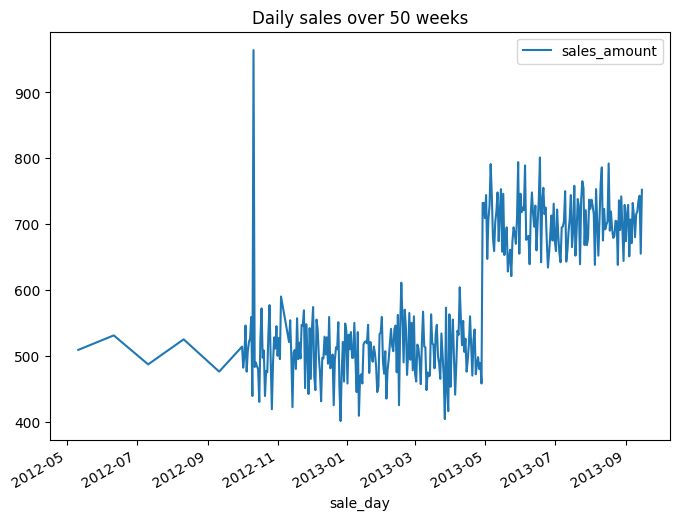

In [14]:
#  to use index in plotting make sale_day index
daily_sales_df.index = daily_sales_df['sale_day']
daily_sales_df.drop(columns=['sale_day'], inplace=True)

#  plot daily sales for all 50 weeks
daily_sales_df.plot(figsize=FIG_SIZE, title = "Daily sales over 50 weeks")
plt.show()

## Question 2

**It looks like there has been a sudden change in daily sales. What date did it occur?**

In [15]:
daily_sales_df['prev_day_sale_amount'] = [None] + daily_sales_df['sales_amount'].to_list()[:-1]
daily_sales_df['difference_btw_prev_day'] = daily_sales_df['sales_amount'] - daily_sales_df['prev_day_sale_amount']
daily_sales_df

,sales_amount,prev_day_sale_amount,difference_btw_prev_day
sale_day,,,
2012-05-11,509,NaN,NaN
2012-06-11,531,509.0,22.0
2012-07-11,487,531.0,-44.0
2012-08-11,525,487.0,38.0
2012-09-11,476,525.0,-49.0
...,...,...,...
2013-09-11,719,715.0,4.0
2013-09-12,735,719.0,16.0
2013-09-13,743,735.0,8.0


In [18]:
daily_sales_df[daily_sales_df.index == '2013-04-29']

,sales_amount,prev_day_sale_amount,difference_btw_prev_day
sale_day,,,
2013-04-29,732,458.0,274.0


## Question 3

Is the change in daily sales at the date you selected statistically significant? If so, what is the p-value?

In [19]:
from scipy import stats

daily_sales_df.dropna(inplace=True)
stats.ttest_1samp(daily_sales_df['sales_amount'], 732)

TtestResult(statistic=-25.501659836864523, pvalue=1.4856585268485893e-81, df=347)

The obtained p-value as the result of the t-test is 1.3019593251472396e-84 which is lower than 0.05 (we can assume the threshold as 0.05 as common practice). It leads to decide this particular date is important for us.

## Question 4

**Does the data suggest that the change in daily sales is due to a shift in the proportion of male-vs-female customers? Please use plots to support your answer (a rigorous statistical analysis is not necessary).**

In [21]:
df['sale_day'] = pd.to_datetime(df['sale_time'], format='mixed').dt.floor('d')
gender_portions_df = df.groupby(['sale_day', 'purchaser_gender']).size().reset_index(name='sales_amount')
gender_portions_df

,sale_day,purchaser_gender,sales_amount
0,2012-05-11,female,368
1,2012-05-11,male,141
2,2012-06-11,female,404
3,2012-06-11,male,127
4,2012-07-11,female,345
...,...,...,...
693,2013-09-13,male,537
694,2013-09-14,female,193
695,2013-09-14,male,462
696,2013-09-15,female,230


In [22]:
new_df = pd.DataFrame(gender_portions_df['sale_day'].unique(),columns=['sale_day'])
new_df['female_sales_amount'] = pd.Series(gender_portions_df[gender_portions_df.purchaser_gender == 'female']['sales_amount']).reset_index(drop=True)
new_df['male_sales_amount'] = pd.Series(gender_portions_df[gender_portions_df.purchaser_gender == 'male']['sales_amount']).reset_index(drop=True)
new_df[-5:]

,sale_day,female_sales_amount,male_sales_amount
344,2013-09-11,224,495
345,2013-09-12,225,510
346,2013-09-13,206,537
347,2013-09-14,193,462
348,2013-09-15,230,522


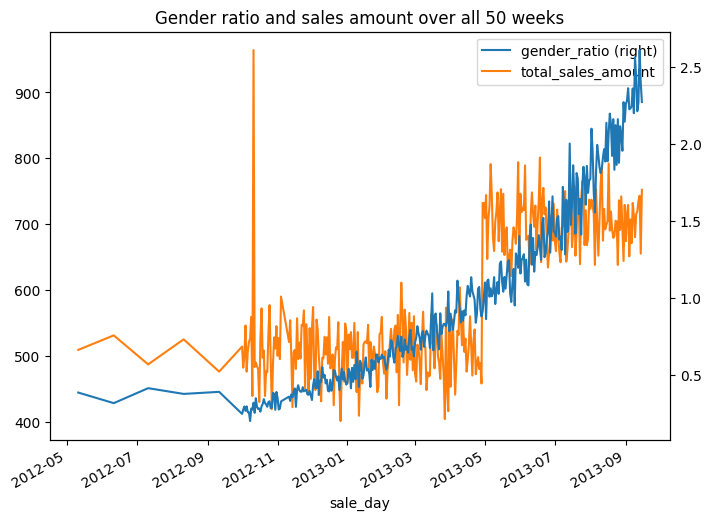

In [23]:
new_df['gender_ratio'] = new_df['male_sales_amount']/new_df['female_sales_amount']

# plot gender ratio change over 50 weeks with the total sales amount
# observe if there is a correlation between them
plot_df = new_df.copy()
plot_df['total_sales_amount']  = plot_df['male_sales_amount'] + plot_df['female_sales_amount']
plot_df.drop(columns=['female_sales_amount', 'male_sales_amount'], inplace=True)
plot_df.index = plot_df['sale_day']
plot_df.drop(columns=['sale_day'], inplace=True)
plot_df.plot(secondary_y = ['gender_ratio'],figsize=FIG_SIZE, title= "Gender ratio and sales amount over all 50 weeks")
plt.show()

The increasing trend of the male ratio in the sales amount does not explain the sudden change. The reason should be something different. For example, it might be caused by starting a new marketing campaign or adding a new feature to the website.

## Question 5

**Assume a given day is divided into four dayparts: night (12:00AM - 6:00AM), morning (6:00AM to 12:00PM), afternoon (12:00PM to 6:00PM) and evening (6:00PM - 12:00AM). What is the percentage of sales in each daypart over all 50 weeks?**

In [25]:
df['sale_hour']  = pd.to_datetime(df['sale_time'], format='mixed').dt.ceil('h').dt.hour
df.dtypes

sale_time                   object
purchaser_gender            object
sale_day            datetime64[ns]
sale_hour                    int32
dtype: object

Define a function to apply sale hour column to decide a part of day based on the mentioned logic

In [26]:
def assign_day_part(sale_hour):
    """Assign labels based on sale hour."""
    if sale_hour >= 6 and sale_hour < 12:
        return 'morning'
    if sale_hour >= 12 and sale_hour < 18:
        return 'afternoon'
    if sale_hour >= 18 and sale_hour < 24:
        return 'evening'
    if sale_hour >= 0 and sale_hour < 6:
        return 'night'

In [27]:
# apply the defined function and create day_part column
df['day_part'] = df['sale_hour'].apply(assign_day_part)

# drop unnecessary columns
df.drop(columns = ['purchaser_gender', 'sale_hour', 'sale_time'], inplace= True)

# calculate sales amount per day part
df_pct_sales = df.groupby(df.day_part).size().reset_index(name='day_part_sales_amount')

# calculate sales amount percentage per day part
df_pct_sales['day_part_sales_percentage'] = df_pct_sales['day_part_sales_amount'] / df_pct_sales['day_part_sales_amount'].sum()

df_pct_sales

,day_part,day_part_sales_amount,day_part_sales_percentage
0,afternoon,81160,0.397203
1,evening,53516,0.261911
2,morning,56083,0.274474
3,night,13570,0.066413
